In [3]:
import os
# THIS IS THE MAGIC SWITCH! It must happen before importing TF
os.environ['TF_USE_LEGACY_KERAS'] = '1' 

import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__} (Running in Legacy Keras 2 Mode!)")
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0 (Running in Legacy Keras 2 Mode!)
TensorFlow Version: 2.19.0


In [4]:
file = pd.read_csv("/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv")
df = file.copy()
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [5]:
df_clean = df.copy()

# 1. Map ordinal categories (things with a clear order)
map_social = {'low': 0, 'medium': 1, 'high': 2}
df_clean["social_interaction_level"] = df_clean["social_interaction_level"].map(map_social)

# 2. One-hot encode nominal categories (things without an order, like Gender/Platform)
# dtype=float ensures it outputs 1.0 and 0.0 instead of True/False
df_clean = pd.get_dummies(df_clean, columns=['gender', 'platform_usage'], dtype=float)

print(df_clean.head())

   age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0   14                       7.9          7.4                       2.9   
1   19                       1.9          8.0                       2.9   
2   17                       1.3          7.6                       0.5   
3   15                       7.4          6.9                       1.6   
4   15                       4.7          4.9                       3.0   

   academic_performance  physical_activity  social_interaction_level  \
0                  3.01                1.5                         0   
1                  3.22                0.8                         2   
2                  3.92                0.0                         2   
3                  3.48                0.8                         1   
4                  2.37                1.4                         1   

   stress_level  anxiety_level  addiction_level  depression_label  \
0             2              2                1

In [6]:
# Drop the label from X, and isolate it in y
X = df_clean.drop('depression_label', axis=1).astype(np.float32)
y = df_clean['depression_label'].astype(np.float32)

print(f"X shape (rows, columns): {X.shape}")
print(f"y shape (rows): {y.shape}")

X shape (rows, columns): (1200, 15)
y shape (rows): (1200,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

Training data: 960 rows
Testing data: 240 rows


In [8]:
# Calculate the mean and standard deviation of the training data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Replace any zeroes in std with a tiny number to prevent divide-by-zero crashes
train_std = np.where(train_std == 0, 1e-7, train_std)

# Scale the data
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print("--- YOU WILL NEED TO COPY THESE TO script.js LATER ---")
print("const trainMean =", list(train_mean))
print("const trainStd =", list(train_std))

--- YOU WILL NEED TO COPY THESE TO script.js LATER ---
const trainMean = [15.958333015441895, 4.543541431427002, 6.4574995040893555, 1.7423957586288452, 2.9948747158050537, 1.0020833015441895, 0.9645833373069763, 5.415625095367432, 5.555208206176758, 5.573958396911621, 0.4906249940395355, 0.5093749761581421, 0.3343749940395355, 0.3385416567325592, 0.3270833194255829]
const trainStd = [np.float32(2.041366), np.float32(2.031873), np.float32(1.4468133), np.float32(0.71886784), np.float32(0.5778394), np.float32(0.5810128), np.float32(0.8071598), np.float32(2.9314685), np.float32(2.85066), np.float32(2.8465753), np.float32(0.50017077), np.float32(0.50017077), np.float32(0.47201562), np.float32(0.4734602), np.float32(0.4693928)]


In [9]:
X_test_scaled.tail()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
382,-0.469457,-0.169076,0.236728,-0.893621,0.649186,-0.519925,1.282790,-0.824032,0.156031,0.852267,1.018402,-1.018402,-0.708398,-0.715037,1.433590
867,1.000147,-0.661233,0.927902,-1.450052,0.804939,0.512754,-1.195034,-0.141781,1.559215,0.149668,1.018402,-1.018402,1.410176,-0.715037,-0.696822
542,1.000147,-1.202605,0.167610,-1.171837,1.272197,-0.519925,-1.195034,-0.824032,-0.194765,0.500967,1.018402,-1.018402,1.410176,-0.715037,-0.696822
1193,-1.449193,1.307394,1.135254,0.497455,-0.821811,-1.036265,0.043878,-0.824032,-0.896357,0.500967,1.018402,-1.018402,-0.708398,1.397073,-0.696822
874,-0.959325,-1.399468,0.029375,1.332101,-1.617880,-1.552605,0.043878,1.222723,-0.194765,1.203566,1.018402,-1.018402,-0.708398,-0.715037,1.433590


In [10]:
# Automatically get the correct number of input columns (should be 15)
input_dim = X_train_scaled.shape[1]

# Build the Sequential model
model = keras.Sequential([
    layers.InputLayer(input_shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2), # Stops the model from cheating/memorizing
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Outputs a percentage between 0 and 1
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                512       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1057 (4.13 KB)
Trainable params: 1057 (4.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-05-09 10:28:36.809642: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Train the model!
print("Starting training...")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=50, 
    batch_size=16, 
    validation_split=0.2, # Holds back another 20% just to double-check itself
    verbose=1
)

Starting training...
Epoch 1/50
48/48 [==============================] - 1s 7ms/step - loss: 0.3401 - accuracy: 0.9414 - val_loss: 0.2265 - val_accuracy: 0.9583
Epoch 2/50
48/48 [==============================] - 0s 3ms/step - loss: 0.1466 - accuracy: 0.9779 - val_loss: 0.1664 - val_accuracy: 0.9583
Epoch 3/50
48/48 [==============================] - 0s 3ms/step - loss: 0.1022 - accuracy: 0.9779 - val_loss: 0.1544 - val_accuracy: 0.9583
Epoch 4/50
48/48 [==============================] - 0s 3ms/step - loss: 0.0942 - accuracy: 0.9779 - val_loss: 0.1470 - val_accuracy: 0.9583
Epoch 5/50
48/48 [==============================] - 0s 3ms/step - loss: 0.0814 - accuracy: 0.9779 - val_loss: 0.1413 - val_accuracy: 0.9583
Epoch 6/50
48/48 [==============================] - 0s 3ms/step - loss: 0.0764 - accuracy: 0.9779 - val_loss: 0.1327 - val_accuracy: 0.9583
Epoch 7/50
48/48 [==============================] - 0s 3ms/step - loss: 0.0681 - accuracy: 0.9779 - val_loss: 0.1275 - val_accuracy: 0.9583

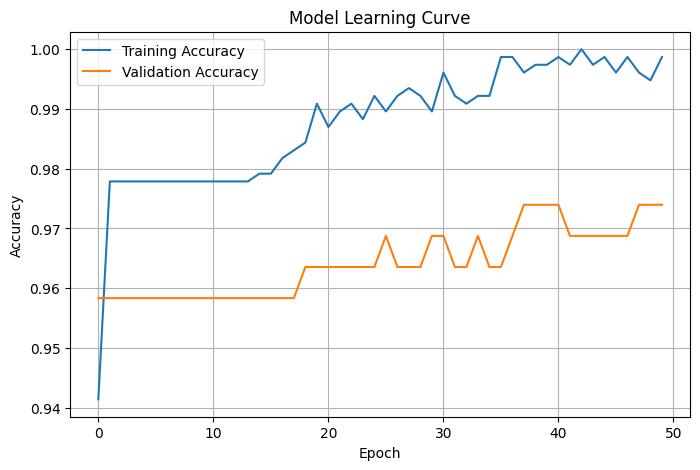


--- Final Exam on Unseen Data ---
8/8 [==============================] - 0s 2ms/step - loss: 0.0756 - accuracy: 0.9750
Realistic Test Accuracy: 97.50%


In [12]:
# Let's plot the learning curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Learning Curve')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# The ultimate test
print("\n--- Final Exam on Unseen Data ---")
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Realistic Test Accuracy: {accuracy * 100:.2f}%")

In [13]:
# Save the model in the stable .h5 format
model.save("depression_model.h5")
print("\n✅ Model successfully saved as depression_model.h5!")
print("Download this file from the Kaggle output panel and upload it to Hugging Face.")


✅ Model successfully saved as depression_model.h5!
Download this file from the Kaggle output panel and upload it to Hugging Face.


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
